https://snap.stanford.edu/data/ego-Facebook.html

In [4]:
import networkx as nx
from node2vec import Node2Vec

# =========================
# 1. Đọc dữ liệu edge list
# =========================

file_path = "facebook_combined.txt"

# Vì file có dạng:
# 0 1
# 0 2
# 1 48
# nên dùng read_edgelist
G = nx.read_edgelist(
    file_path,
    nodetype=str,
    create_using=nx.Graph()
)

print("Số lượng node:", G.number_of_nodes())
print("Số lượng edge:", G.number_of_edges())


# =========================
# 2. Train Node2Vec
# =========================

node2vec = Node2Vec(
    G,
    dimensions=64,      # số chiều vector embedding
    walk_length=30,     # độ dài mỗi random walk
    num_walks=100,      # số lần random walk cho mỗi node
    workers=4,          # số luồng xử lý
    p=1,                # return parameter
    q=1                 # in-out parameter
)

model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4
)


# =========================
# 3. Lưu model và embedding
# =========================

model.save("node2vec_facebook.model")
model.wv.save_word2vec_format("facebook_embeddings.txt")

print("Train xong và đã lưu model.")

Số lượng node: 4039
Số lượng edge: 88234


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Train xong và đã lưu model.


Kmean trên embedding

In [10]:
# KMeans trên embedding Node2Vec

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# =========================
# 1. Lấy embedding từ model Node2Vec
# =========================

nodes = model.wv.index_to_key
embeddings = np.array([model.wv[node] for node in nodes])

print("Số node:", len(nodes))
print("Kích thước embeddings:", embeddings.shape)


# =========================
# 2. Chọn số cụm K tự động
# =========================

k_range = range(6, 12)
best_k = None
best_score = -1

for k in k_range:
    km_tmp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels_tmp = km_tmp.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels_tmp)

    print(f"k={k}, silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest k = {best_k}, best silhouette = {best_score:.4f}")


# =========================
# 3. Train KMeans với K tốt nhất
# =========================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(embeddings)


# =========================
# 4. Gán cụm cho từng user
# =========================

df_cluster = pd.DataFrame({
    "user_id": nodes,
    "cluster": cluster_labels
})

display(df_cluster.head(20))


# =========================
# 5. Xem số lượng user trong từng cụm
# =========================

cluster_counts = df_cluster["cluster"].value_counts().sort_index()

print("\nSố lượng user trong từng cụm:")
print(cluster_counts)




Số node: 4039
Kích thước embeddings: (4039, 64)
k=6, silhouette=0.2758
k=7, silhouette=0.2813
k=8, silhouette=0.2581
k=9, silhouette=0.2471
k=10, silhouette=0.2279
k=11, silhouette=0.2346

Best k = 7, best silhouette = 0.2813


,user_id,cluster
0,3437,3
1,107,1
2,1684,0
3,0,6
4,1912,2
5,686,4
6,3980,5
7,348,5
8,414,5
9,483,5



Số lượng user trong từng cụm:
cluster
0     785
1    1011
2     752
3     546
4     208
5     396
6     341
Name: count, dtype: int64


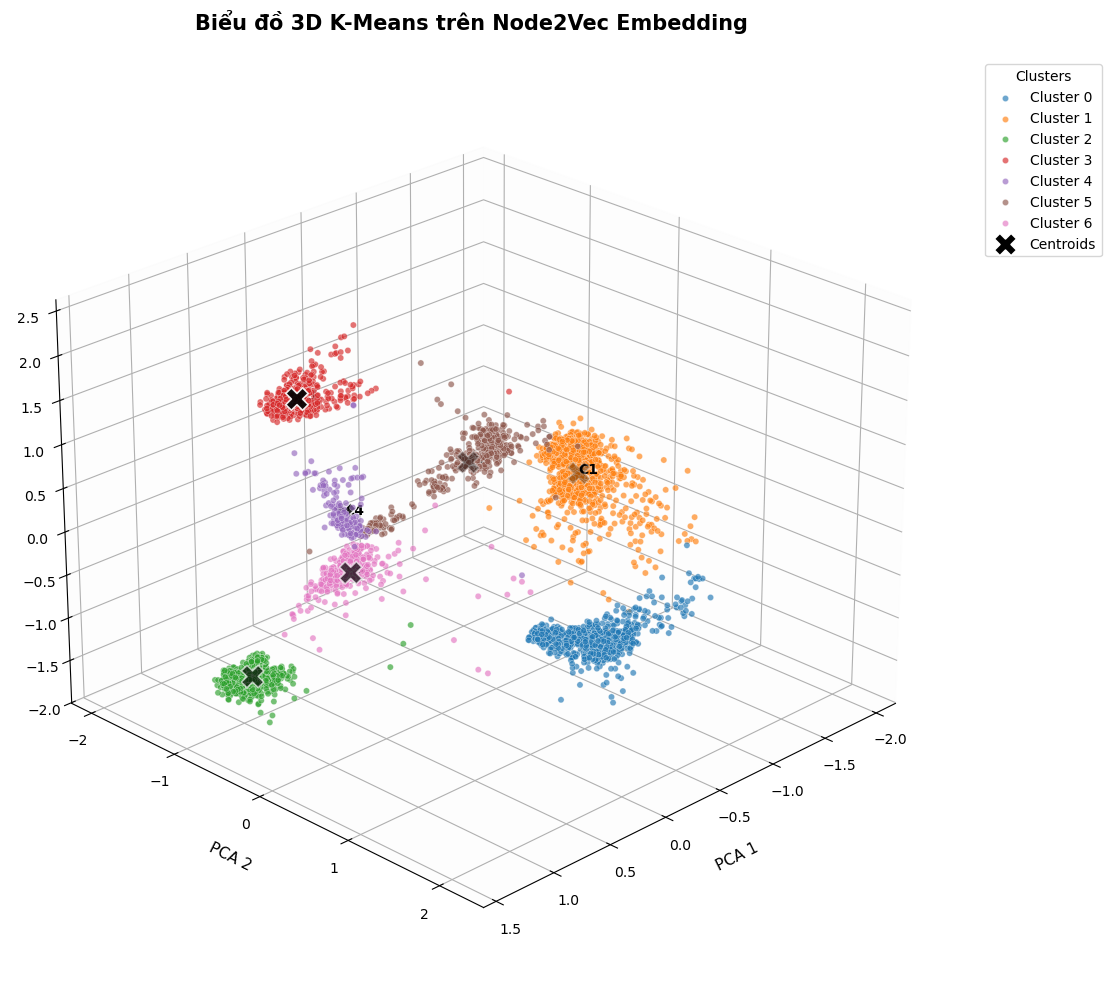

In [16]:
# =========================
# Vẽ biểu đồ 3D đẹp hơn cho K-Means trên Node2Vec Embedding
# =========================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# =========================
# 1. PCA 3D
# =========================
pca_3d = PCA(n_components=3, random_state=42)
embedding_3d = pca_3d.fit_transform(embeddings)

# Chuyển tâm cụm sang không gian PCA 3D
centroids_3d = pca_3d.transform(kmeans.cluster_centers_)

# =========================
# 2. Tạo figure
# =========================
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection="3d")

# =========================
# 3. Vẽ từng cụm
# =========================
for cluster_id in sorted(df_cluster["cluster"].unique()):
    points = embedding_3d[cluster_labels == cluster_id]

    ax.scatter(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        s=20,                 # tăng kích thước điểm
        alpha=0.65,           # hơi trong suốt để đỡ rối
        edgecolors="white",   # viền trắng cho đẹp hơn
        linewidths=0.3,
        label=f"Cluster {cluster_id}"
    )

# =========================
# 4. Vẽ tâm cụm
# =========================
ax.scatter(
    centroids_3d[:, 0],
    centroids_3d[:, 1],
    centroids_3d[:, 2],
    s=260,
    marker="X",
    c="black",
    edgecolors="white",
    linewidths=1.2,
    label="Centroids"
)

# Gắn nhãn cho tâm cụm
for i, center in enumerate(centroids_3d):
    ax.text(
        center[0],
        center[1],
        center[2],
        f"C{i}",
        fontsize=10,
        fontweight="bold"
    )

# =========================
# 5. Tùy chỉnh giao diện
# =========================
ax.set_title(
    "Biểu đồ 3D K-Means trên Node2Vec Embedding",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("PCA 1", fontsize=11, labelpad=10)
ax.set_ylabel("PCA 2", fontsize=11, labelpad=10)
ax.set_zlabel("PCA 3", fontsize=11, labelpad=10)

# Góc nhìn đẹp hơn
ax.view_init(elev=25, azim=45)

# Làm nền sáng hơn
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True

ax.xaxis.pane.set_alpha(0.08)
ax.yaxis.pane.set_alpha(0.08)
ax.zaxis.pane.set_alpha(0.08)

# Grid nhẹ hơn
ax.grid(True, linestyle="--", alpha=0.3)

# Legend đặt ra ngoài cho đỡ che điểm
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    title="Clusters"
)

plt.tight_layout()
plt.show()

In [12]:
# xem vector embeding sau khi train của user 0
user_id = "0"

if user_id in model.wv:
    vector = model.wv[user_id]

    print("Vector embedding của user:", user_id)
    print(vector)
    print("Số chiều vector:", len(vector))
else:
    print("User không tồn tại trong model")

Vector embedding của user: 0
[ 3.5116076e-01 -2.6547035e-02  8.5155123e-01 -4.6703824e-01
  6.4604837e-01 -5.1469517e-01 -1.6933279e-01 -3.2027414e-01
 -2.1644217e-01  3.6158699e-03  3.7320575e-01  1.0550338e-01
  3.1905450e-02 -7.0700330e-01  8.5453093e-02  4.8196501e-01
 -7.4949276e-01  7.9133205e-02 -1.3335647e-01 -1.3077036e-01
  1.2809080e+00  3.4559885e-01  1.8166603e-01 -7.8470576e-01
 -2.9919049e-01  6.2529391e-01 -5.6585324e-01  3.0600619e-02
 -1.1151109e+00 -2.1106462e-01 -1.1884476e-01 -4.0675053e-01
 -1.7727244e-01 -6.4449483e-01  1.7707717e-01  2.1339121e-01
 -1.0472798e+00 -1.2556006e-01 -3.7733205e-02 -3.0548972e-01
 -3.0653226e-01  4.0423506e-01 -5.5069411e-01  1.9832842e-01
  1.3550548e-02  1.7467754e-01  3.2522896e-01 -5.4005653e-01
 -5.7998770e-01  1.3370666e-01  1.5647845e-02  2.7385771e-01
 -1.8450357e-01  2.4407844e-01  2.0756744e-01 -7.9729612e-04
 -5.1402457e-02 -2.0530930e-01  4.9169511e-02 -5.5355337e-02
 -1.2488925e-01 -3.9585370e-01  3.8457996e-01 -2.7870116

In [13]:
# Xem 5 user đầu tiên trong model
for user_id in model.wv.index_to_key[:5]:
    print("User:", user_id)
    print(model.wv[user_id])
    print("Số chiều:", len(model.wv[user_id]))
    print("-" * 50)

User: 3437
[ 0.4243523   0.11654215  0.48601872  0.57504165 -0.3496602  -0.266749
  0.26145583 -0.06234042 -0.15462475  0.38347802  0.67315054 -0.32959569
 -0.28465807 -0.20451415 -0.5774518  -0.37723747 -0.395714   -0.4421152
 -0.8254125   0.0454889   0.5239278   0.5034659   0.09314542 -0.6636922
  0.1093809  -0.01044686 -0.32343075  0.60572916 -0.72916293  0.3217937
 -0.46031773  0.6559457  -0.44344217 -0.38302246  0.4503661  -0.17362571
 -0.04638913 -0.29175845  0.25924107  0.36149576 -0.3626796   0.19732444
 -0.471106   -0.08159586 -0.18699907 -0.05384837 -0.58593696 -0.18703476
 -0.21296011 -0.39963824 -0.20006678  0.3258577   0.46221173  0.30427805
  0.57887733 -0.42226648  0.3221357  -0.8956159  -0.9390514   0.40884724
 -0.00100985  0.13057026  0.32265806 -0.22302315]
Số chiều: 64
--------------------------------------------------
User: 107
[ 0.05933115 -0.04016749  0.6597028   0.2147227  -0.07591996 -0.26906735
  0.14091173 -0.03412475  0.20045578 -0.27380264  0.31334814  0.212

In [14]:
# Tạo ma trận cosine similarity từ embedding Node2Vec

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# =========================
# 1. Lấy danh sách user có trong model
# =========================
nodes = model.wv.index_to_key

# =========================
# 2. Lấy embedding tương ứng từng user
# =========================
embeddings = np.array([model.wv[node] for node in nodes])

print("Số lượng user:", len(nodes))
print("Kích thước embeddings:", embeddings.shape)

# =========================
# 3. Tạo ma trận cosine similarity
# =========================
sim_matrix = cosine_similarity(embeddings)

print("sim_matrix shape:", sim_matrix.shape)

# =========================
# 4. Đưa ma trận về DataFrame cho dễ xem
# =========================
df_sim = pd.DataFrame(
    sim_matrix,
    index=nodes,
    columns=nodes
)

# Xem góc 10x10
display(df_sim.iloc[:10, :10])

# =========================
# 5. Kiểm tra cosine của một user với chính nó
# =========================
user_id = "0"

if user_id in df_sim.index:
    print(f"Cosine({user_id}, {user_id}) =", df_sim.loc[user_id, user_id])
else:
    print("User không tồn tại trong ma trận")

Số lượng user: 4039
Kích thước embeddings: (4039, 64)
sim_matrix shape: (4039, 4039)


,3437,107,1684,0,1912,686,3980,348,414,483
3437,1.000000,0.239308,0.300613,0.343364,0.274377,0.467997,0.439083,0.310105,0.344745,0.300058
107,0.239308,1.000000,0.257827,0.332858,0.213610,0.261099,0.302154,0.428013,0.432479,0.644942
1684,0.300613,0.257827,1.000000,0.351588,0.213097,0.349381,0.353092,0.213283,0.224658,0.161886
0,0.343364,0.332858,0.351588,1.000000,0.434203,0.410931,0.429723,0.492584,0.451723,0.316846
1912,0.274377,0.213610,0.213097,0.434203,1.000000,0.329836,0.418768,0.297641,0.251153,0.292717
686,0.467997,0.261099,0.349381,0.410931,0.329836,1.000000,0.476336,0.347919,0.355232,0.302139
3980,0.439083,0.302154,0.353092,0.429723,0.418768,0.476336,1.000000,0.449239,0.614869,0.400410
348,0.310105,0.428013,0.213283,0.492584,0.297641,0.347919,0.449239,1.000000,0.701277,0.686105
414,0.344745,0.432479,0.224658,0.451723,0.251153,0.355232,0.614869,0.701277,1.000000,0.649194
483,0.300058,0.644942,0.161886,0.316846,0.292717,0.302139,0.400410,0.686105,0.649194,1.000000


Cosine(0, 0) = 0.9999998
